#### Używamy szybkiej transformaty Fouriera, aby przekształcić .wav, nasz szereg czasowy, ze skali czasu na skalę częstotliwości.

Spectral leakage -


#### Skorzystamy ze zbioru danych TinySOL (URL: https://zenodo.org/records/3685367)
#### W tym celu pobieramy bibliotekę mirdata zawierającą dataset loader

In [1]:
#import pandas as pd
import numpy as np

import wave
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf

from IPython.display import Audio, display
from pathlib import Path

In [2]:
# Szukamy plików .wav
dataset_path = Path('tiny_data')
audio_files = sorted(list(dataset_path.rglob("*.wav")))

print(f"Znalezione pliki .wav: {len(audio_files)}")

Znalezione pliki .wav: 3


In [3]:
# Przykładowy plik
sample_file = audio_files[1]
audio_signal, sample_rate = sf.read(sample_file)

file_name = sample_file.stem
metadata = file_name.split('-')

print(f"Plik {sample_file.name}")
print(f"Kod instrumentu: {metadata[0]}, Nuta: {metadata[2]}, Dynamika: {metadata[3]}")
print(f"Częstotliwość próbkowania: {sample_rate} Hz | Liczba próbek: {audio_signal.shape[0]}")

# Konwersja pliku do mono (jeśli był w stereo)
if audio_signal.ndim > 1:
    audio_signal = np.mean(audio_signal, axis = 1)

# Odtwarzacz
display(Audio(audio_signal, rate = sample_rate))



Plik MelSpectrogram_Implementation_tiny_data_Contrabass_ordinario_Cb-ord-G4-mf-1c-N.wav
Kod instrumentu: MelSpectrogram_Implementation_tiny_data_Contrabass_ordinario_Cb, Nuta: G4, Dynamika: mf
Częstotliwość próbkowania: 44100 Hz | Liczba próbek: 193577


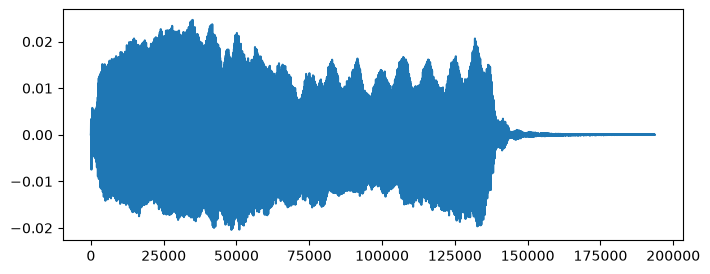

In [4]:
plt.figure(figsize=(8,3))
plt.plot(audio_signal) # "Żuk Mandelbrota"
plt.show()

In [5]:
def plot_audiowave(signal, sr = 44100, zoom_ms = 50,figsize = (12,8)):
    number_of_samples = len(signal)
    duration_seconds = number_of_samples/sr

    t = np.arange(len(signal))/ sr
    peak_amp = np.max(np.abs(signal))

    fig, (ax, ax_zoom) = plt.subplots(2,1, figsize = figsize)

    # Pełny sygnał
    ax.plot(t,signal,linewidth =.6, alpha =.8, label = "Amplituda")
    ax.set_xlim(0, duration_seconds)
    #ax.set_ylim(-0.5, 0.5)
    ax.set_ylabel("Amplituda")
    ax.set_xlabel("Czas [s]")
    ax.grid(True, linestyle="-", alpha=0.5)

    # Wycinek sygnału
    zoom_start_sec = max(0.0, (duration_seconds / 2) - (zoom_ms / 2000.0))
    zoom_end_sec = min(duration_seconds, zoom_start_sec + (zoom_ms / 1000.0))
    ax.axvspan(
        zoom_start_sec,
        zoom_end_sec,
        color="orange",
        alpha=0.3,
        label=f"Wycinek ({zoom_ms} ms)",
    )
    ax.legend(loc="upper right", framealpha=0.9)

    start_idx = int(zoom_start_sec * sr)
    end_idx = int(zoom_end_sec * sr)

    t_zoom_ms = (t[start_idx:end_idx] - zoom_start_sec) * 1000.0
    signal_zoom = signal[start_idx:end_idx]

    ax_zoom.plot(
        t_zoom_ms,
        signal_zoom,
        color="red",
        linewidth=1.5,
        markersize=2,
    )
    ax_zoom.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.6)
    ax_zoom.set_xlim(0, (zoom_end_sec - zoom_start_sec) * 1000.0)
    ax_zoom.set_ylabel("Amplituda")
    ax_zoom.set_xlabel("Czas [ms]")
    ax_zoom.set_title(
        f"Fragment fali (okno {zoom_ms} ms)",
        fontsize=10,
    )
    ax_zoom.grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


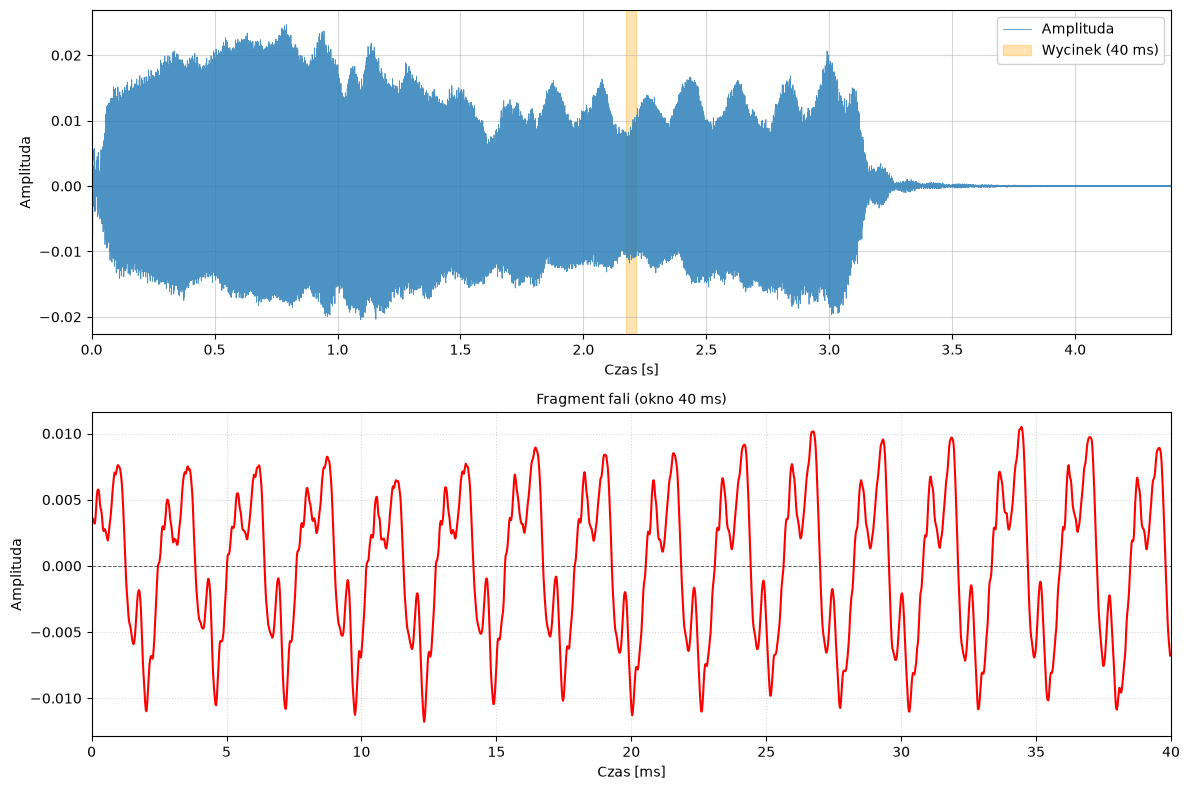

In [6]:
plot_audiowave(audio_signal, zoom_ms= 40)

### Etap 1. Framing + Overlap
Musimy pociąć plik audio na fragmenty (okna, które nachodzą na siebie). Musimy zdefiniować parametry:
- długość okna $N$,
- krok przesunięcia $H$,
- liczba ramek $K$.

Dodajemy też padding, czyli wstawiamy N/2 zer na początku sygnały, aby środek pierwszego okna był w chwili $t_0 = 0$.
Dzięki temu lepiej uchwycimy co się dzieje na początku dźwięku (np. okno Hanna ma największą wartość w połowie przedziału).

Możemy zrobić padding zerami albo użyć odbicia.

In [114]:
def signal_zero_padding(audio_data, window_len = 1024, step_len = 512):

    audio_data = np.asarray(audio_data)
    padding_left = window_len//2
    num_samples = len(audio_data)
    r = num_samples%step_len

    if r != 0:
        add_right = step_len - r
    else:
        add_right = 0

    padding_right = window_len//2 + add_right


    padded_signal = np.zeros(padding_left + num_samples + padding_right, dtype=audio_data.dtype)
    padded_signal[padding_left: padding_left+num_samples] = audio_data

    return padded_signal


def signal_reflect_padding(audio_data, window_len = 1024, step_len = 512):

    audio_data = np.asarray(audio_data)
    padding_left = window_len//2
    num_samples = len(audio_data)
    r = num_samples%step_len

    if r != 0:
            add_right = step_len - r
    else:
        add_right = 0
    
    padding_right = window_len//2 + add_right

    pad_left = audio_data[1:padding_left+1][::-1]
    pad_right = audio_data[-1-padding_right : -1][::-1]

    padded_signal = np.concatenate([pad_left, audio_data, pad_right])

    return padded_signal
    

In [115]:
padded_signal_reflect = signal_reflect_padding(audio_signal)
len(padded_signal_reflect)

195072

In [116]:
padded_signal = signal_zero_padding(audio_signal)
len(padded_signal)

195072

Chcemy macierz 2D o wymiarach (M,N)
- M - liczba ramek
- N - długość pojedynczej ramki (np. 1024)


In [119]:
def frame_audio(audio_data, window_len = 1024, step_len = 512, sr = 44100):

    audio_data = np.asarray(audio_data)
    num_of_samples = len(audio_data)
    number_frames = (num_of_samples-window_len)//step_len + 1

    frames = np.empty((number_frames,window_len), dtype=audio_data.dtype)
    
    for i in range(number_frames):
        start = i*step_len
        frames[i] = audio_data[start: window_len + start]

    return frames

In [124]:
sliced_audio = frame_audio(audio_data=padded_signal_reflect)
sliced_audio.shape

(380, 1024)

In [125]:
# Obsługa wycinków
p = [1,2,3,4,5,6,7,8,9,10] # padding, dokleić 0 na końcu listy

N = 4
H = 2
elem = 10
K = (elem-N)//H +1
#8 -> 6 .> 4
print(K)

for i in range(K):
    print(i*H, N + i*H)
    print(p[i*H: N + i*H])


4
0 4
[1, 2, 3, 4]
2 6
[3, 4, 5, 6]
4 8
[5, 6, 7, 8]
6 10
[7, 8, 9, 10]


### Etap 2. Okienkowanie
Nakładamy funkcję okna na każdą wycietą ramkę.

- Najbardziej popularna: Hann window
- Stosuje się także Hamming window

$$w(n) = 0.5 - 0.5*\cos(\frac{2\pi n}{N-1}), \; \; 0 \le n \le N-1$$

In [126]:
def hann_window(window_len=1024):
    return np.asarray([ (0.5 - 0.5*np.cos(2*np.pi*n/ (window_len-1))) for n in range(window_len) ])

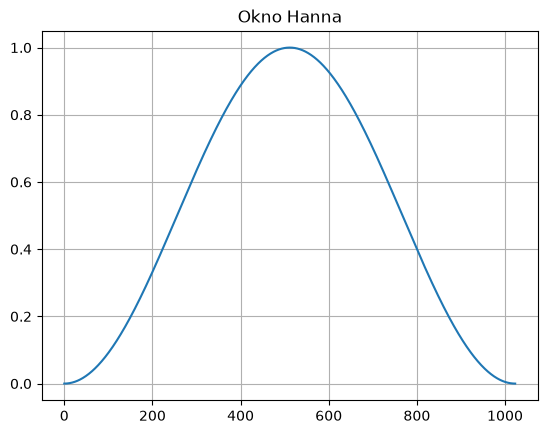

In [127]:
hann_1024 = hann_window(1024)
plt.plot(hann_1024)
plt.grid(True)
plt.title("Okno Hanna")
plt.show()

Teraz należy przemnożyć każdy wycinek sygnału przez okno Hanna.
Operacja ta tłumi nieciągłości na brzegach ramek i minimalizuje przeciek widma (spectral leakage).

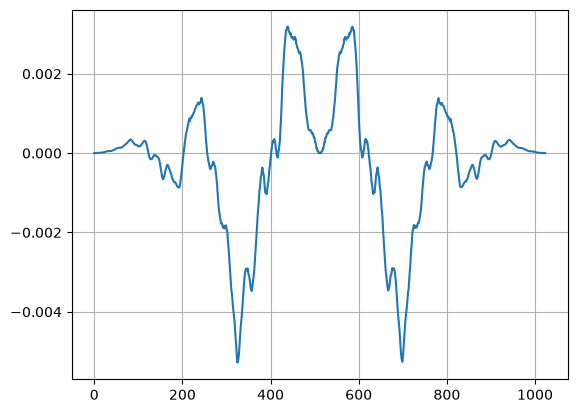

In [133]:
hanned_frames = sliced_audio*hann_1024

plt.plot(hanned_frames[0])
plt.grid(True)
plt.show()

### Etap 3. STFT

Short-Time Fourier Transform to metoda podziału sygnału audio na małe przedziały i stosowanie DFT (Discrete Fourier Transform) na każdym z przedziałów, czyli badamy częstotliwość na takim małym przedziale.

Korzystamy z numerycznej wersji DFT, czyli FFT (Fast Fourier Transform), wymyślona przez Gaussa, przyspiesza obliczenia numeryczne.

Wynikiem jest dwuwymiarowa macierz częstotliwości i czasu, którą najczęściej przedstawia się wizualnie jako spektrogram\

Transformata Fouriera rozkłada sygnał na sumę funkcji $\sin$ i $\cos$

<img src=https://pythonnumericalmethods.studentorg.berkeley.edu/_images/24.02.02-time_frequency.png width="600" alt="Wizualizacja działania transformaty Fouriera">

### Mel Filterbank
Nakładanie filtrów trójkątnych, aby wyeliminować możliwy przeciek widma (spectral leakage)